# MLFLOW - Deploying Machine Learning in Production

In this assignment you will be writing a script that train models and use `mlflow` to submit runs. 

In [1]:
%%writefile ./new_data.json
{"age": {"0": 40, "1": 47},
 "balance": {"0": 580, "1": 3644},
 "campaign": {"0": 1, "1": 2},
 "contact": {"0": "unknown", "1": "unknown"},
 "day": {"0": 16, "1": 9},
 "default": {"0": "no", "1": "no"},
 "duration": {"0": 192, "1": 83},
 "education": {"0": "secondary", "1": "secondary"},
 "housing": {"0": "yes", "1": "no"},
 "job": {"0": "blue-collar", "1": "services"},
 "loan": {"0": "no", "1": "no"},
 "marital": {"0": "married", "1": "single"},
 "month": {"0": "may", "1": "jun"},
 "pdays": {"0": -1, "1": -1},
 "poutcome": {"0": "unknown", "1": "unknown"},
 "previous": {"0": 0, "1": 0}}

Overwriting ./new_data.json


In [4]:
dictionary = json.load(open("./new_data.json"))
dictionary

{'age': {'0': 40, '1': 47},
 'balance': {'0': 580, '1': 3644},
 'campaign': {'0': 1, '1': 2},
 'contact': {'0': 'unknown', '1': 'unknown'},
 'day': {'0': 16, '1': 9},
 'default': {'0': 'no', '1': 'no'},
 'duration': {'0': 192, '1': 83},
 'education': {'0': 'secondary', '1': 'secondary'},
 'housing': {'0': 'yes', '1': 'no'},
 'job': {'0': 'blue-collar', '1': 'services'},
 'loan': {'0': 'no', '1': 'no'},
 'marital': {'0': 'married', '1': 'single'},
 'month': {'0': 'may', '1': 'jun'},
 'pdays': {'0': -1, '1': -1},
 'poutcome': {'0': 'unknown', '1': 'unknown'},
 'previous': {'0': 0, '1': 0}}

In [20]:
dictionary['age']

{'0': 40, '1': 47}

In [5]:
#Load all necessary libraries
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import joblib
import json

# Load Dataset
bank = pd.read_csv('bank-full.csv', delimiter = ';')

# Split data between train and validation
X_train, X_test, y_train, y_test = train_test_split(bank.drop(columns = "y"), bank["y"], 
                                                    test_size = 0.10, random_state = 42)

X_train = X_train.reset_index(drop = True)
X_test = X_test.reset_index(drop = True)


In [3]:
bank

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [ ]:
#data exploration

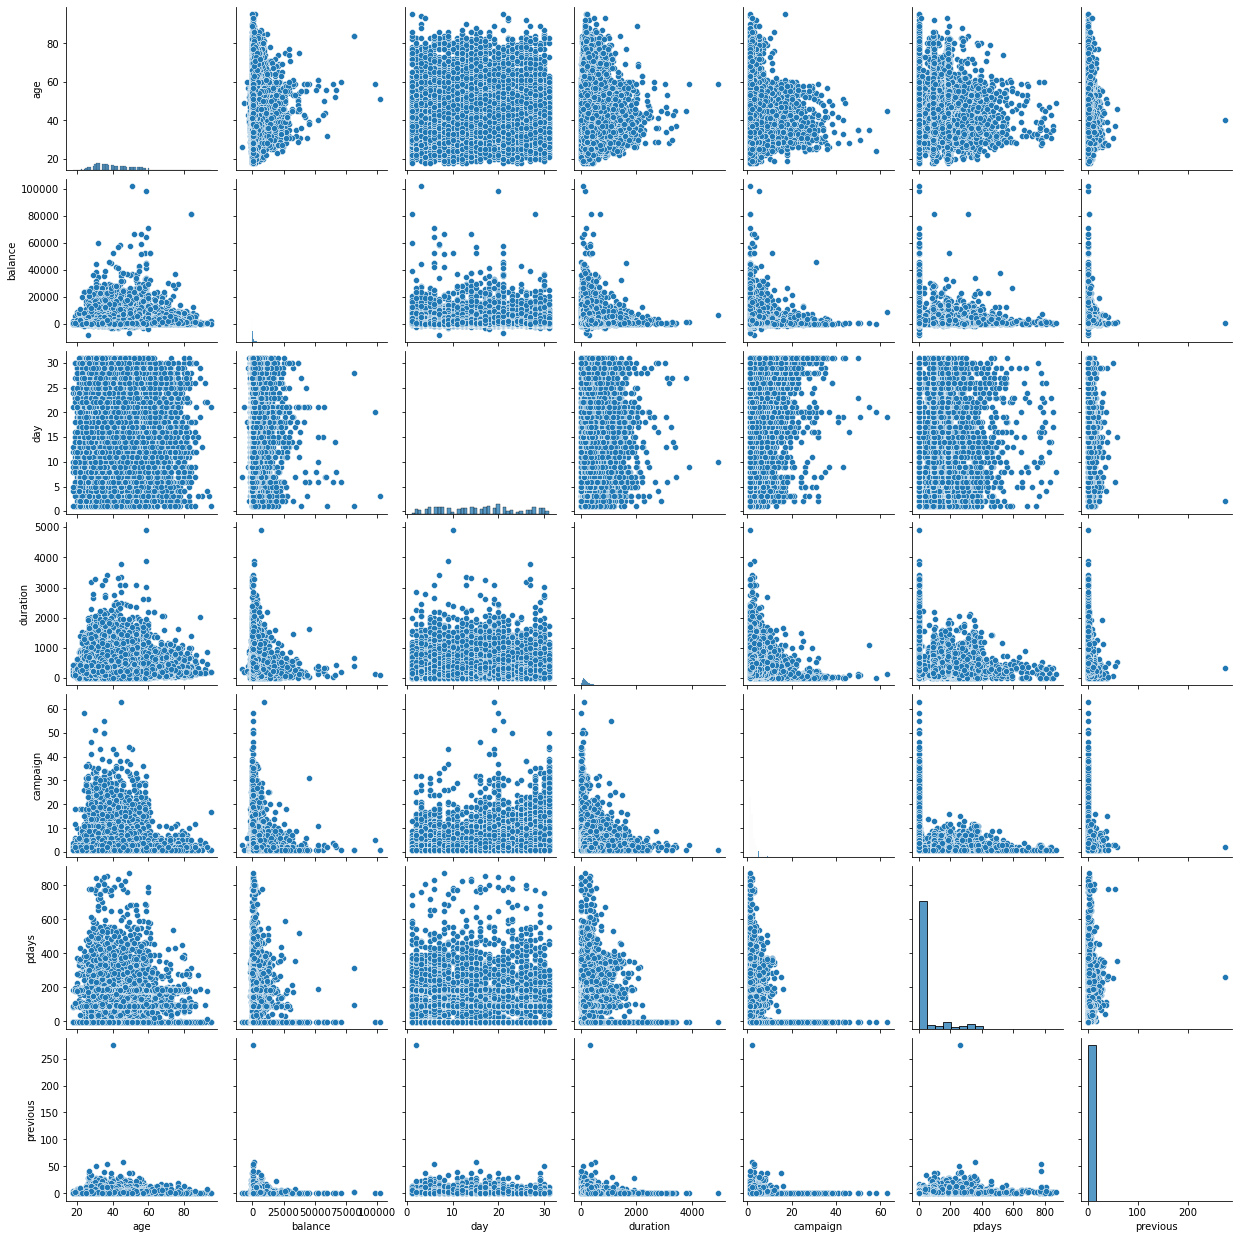

In [6]:
sns.pairplot(bank)

Question 1: Create pre-processing function to be later used as part of the pipeline (custom transformer)

In [12]:
bank['y'].unique()

array(['no', 'yes'], dtype=object)

In [14]:
type(X_train.select_dtypes(['object']).columns)

pandas.core.indexes.base.Index

In [24]:
X_train['age'].dtypes

dtype('int64')

In [17]:
X_train.select_dtypes(['object']).columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

In [25]:
X_train

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,29,housemaid,married,primary,no,0,yes,no,cellular,15,jul,317,3,-1,0,unknown
1,57,management,divorced,secondary,no,396,no,no,cellular,12,aug,108,2,-1,0,unknown
2,54,blue-collar,married,primary,no,714,no,no,cellular,5,may,225,1,-1,0,unknown
3,52,services,married,secondary,no,2072,no,no,cellular,10,jul,224,1,-1,0,unknown
4,34,management,married,tertiary,no,1778,no,no,cellular,4,nov,358,1,162,2,failure
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40684,44,housemaid,single,primary,no,1059,no,no,unknown,18,jun,2093,1,-1,0,unknown
40685,23,student,single,tertiary,no,508,no,no,cellular,8,sep,210,1,92,1,failure
40686,34,technician,divorced,tertiary,no,1317,yes,no,cellular,15,may,239,1,-1,0,unknown
40687,33,retired,married,secondary,no,165,no,no,unknown,7,may,111,1,-1,0,unknown


In [26]:
def transformations(df):
    onehoter = OneHotEncoder(dtype=int) #IP
    cat_cols = X_train.select_dtypes(['object']).columns
    onehot_cols = onehoter.fit(X_train[cat_cols]) #Get Feature Names
    df_onehot = onehoter.transform(df)
   
    num_cols = X_train.select_dtypes(['integer', 'float']).columns
    znormalizer = StandardScaler()
    znormalizer.fit(X_train[num_cols])
    df_norm = znormalizer.transform(df)

    df_featurized = df_onehot 
    df_featurized[num_cols] = df_norm 

    del df_onehot, df_norm
    return df_featurized

Question 2: Creating a custom transformer from the previously defined function

In [ ]:
pre_processing = #To Do ? tf is a custom transformer

Question 3: Creating the pipeline and defining each of two steps: (i) pre-processing, and; (ii) model (Logistic)

In [30]:
pipeline = Pipeline([
    ('model', LogisticRegression())
], verbose=True)

Question 4: Call `fit` and `predict` on the pipeline to make sure that it all works. Remember to pass them the **un-processed** (original) data, since the data processing should be built into the pipeline now.

In [33]:
#Set parameters for Logistic Regression estimator ('model') inside the pipeline
pipeline.set_params(model__C=1.0,                # C: default=1.0
                    model__solver='lbfgs',       # solver: {‘newton-cg’, ‘lbfgs’, ‘liblinear’, ‘sag’, ‘saga’}, default=’lbfgs’
                    model__max_iter=100,         # max_iter: default=100
                    model__fit_intercept=True,   # fit_intercept:{True, False}, default=True
                    model__penalty='l2')         # penalty: {‘l1’, ‘l2’, ‘elasticnet’, ‘none’}, default=’l2’ 
                                                 # Warning: The choice of the algorithm depends on the penalty chosen. 
                                                 #          Not all algorithms support every type of penalty 

#Fit Training Data to Model
pipeline.fit(transformations(X_train), y_train)

#Prediction on Training and Test Data
y_train_pred = pipeline.predict(X_train)
y_test_pred =  pipeline.predict(X_test)



ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- age
- balance
- campaign
- day
- duration
- ...


Question 5: Evaluate your model by calculating the precision and recall.

In [ ]:
#Create a function to evaluate the model performance using precision and recall
def eval_metrics(actual, pred):
    precision = #To Do
    recall = #To Do
    
    return precision, recall

#Calculation of evaluation metrics - Precision and Recall for training and validation data
(precision_train, recall_train) = #To Do
(precision_test, recall_test) = #To Do

# Print Model (Logistic Regression) parameters
print()
print('Main Parameters used in logistic regression are: C={}, solver={}, max_iter={}, fit_intercept={} and penalty={}'.format(pipeline['model'].get_params()['C'],
                                                                                                                             pipeline['model'].get_params()['solver'],
                                                                                                                             pipeline['model'].get_params()['max_iter'],
                                                                                                                             pipeline['model'].get_params()['fit_intercept'],
                                                                                                                             pipeline['model'].get_params()['penalty']))
# Print Evaluation Metrics for the Model (Logistic Regression)
print()
print('Precision = {:.2f}% and recall = {:.2f}% on the training data.'.format(precision_train, recall_train))
print('Precision = {:.2f}% and recall = {:.2f}% on the validation data.'.format(precision_test, recall_test))


Question 6: Save your pipeline object using `joblib` as shown [here](https://sklearn.org/modules/model_persistence.html).

In [ ]:
#store 'pipeline' as pickle file using joblib
#To Do

Question 7: Now write a **new script** for scoring: it loads the pipeline you saved in the last step, reads the data `../data/new_data.json` and converts it to a `pandas.DataFrame` object, and obtains predictions on it. The predictions should be stored as a `json` file `../data/new_preds.json`.

In [ ]:
#Call and load stored 'pipeline' 
pipeline = #To Do

#Read json file with new data and write into a pandas dataframe  
with open('./new_data.json', 'r') as f:
    data = json.load(f)
new_predictions = pd.DataFrame(data)

#Use predict method of pipeline to score (make prediction) on new data 
new_predictions['prediction'] = #To Do

#Write predictions of new data into a json file
new_predictions.to_json('./new_preds.json', orient='columns')

In [ ]:
# Read json file containing predictions made for the new data and load them into a dataframe
with open('./new_preds.json', 'r') as f:
    data = json.load(f)
    
new_pred_dataframe= pd.DataFrame(data)

#Print predictions for each observation contained in the new_data.json file and the dataframe with the data and prediction
print(new_pred_dataframe['prediction'])
new_pred_dataframe

Question 8: Create a new text cell in your Notebook: Complete a 50-100 word summary (or short description of your thinking in applying this week's learning to the solution) of your experience in this assignment. Include: What was your incoming experience with this model, if any? what steps you took, what obstacles you encountered. how you link this exercise to real-world, machine learning problem-solving. (What steps were missing? What else do you need to learn?) This summary allows your instructor to know how you are doing and allot points for your effort in thinking and planning, and making connections to real-world work.